# Lecture 5 - Data Cleaning and Feature Engineering

## 1. Load data

In [190]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.
Path to dataset files: /kaggle/input/cafe-sales-dirty-data-for-cleaning-training


In [191]:
import os
print(os.listdir(path))

['dirty_cafe_sales.csv']


In [192]:
import pandas as pd

In [193]:
data = pd.read_csv(path + "/" + os.listdir(path)[0])

## Show data details

In [194]:
data

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [195]:
data.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [197]:
data.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


## Drop unnecessary columns for model training

In [198]:
data.drop(columns = "Transaction ID", inplace = True)

In [199]:
data

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...
9995,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


## Encode Text-Based Features into Numeric Values

### Show all column's value counts to see all possible values

In [200]:
for i in data.columns:
    print(f"Column: {i}")
    print(data[i].value_counts())
    print("-" * 50)

Column: Item
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64
--------------------------------------------------
Column: Quantity
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64
--------------------------------------------------
Column: Price Per Unit
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64
--------------------------------------------------
Column: Total Spent
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0       444
25.0       259
7.5        237
1.0        232
4.5        225
1.5  

## Create test data

In [201]:
test_data = data.copy()

### Encode the 'Item' Column Using a Mapping Dictionary (map Method)

In [202]:
test_data['Item'].value_counts()

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


In [203]:
item_map = {
    'Juice': 1,
    'Coffee': 2,
    'Salad': 3,
    'Cake': 4,
    'Sandwich': 5,
    'Smoothie': 6,
    'Cookie': 7,
    'Tea': 8,
    'UNKNOWN': -1,
    'ERROR': -2
}

test_data['Item'] = test_data['Item'].map(item_map)

In [204]:
test_data['Item'].value_counts()

,count
Item,
1.0,1171
2.0,1165
3.0,1148
4.0,1139
5.0,1131
6.0,1096
7.0,1092
8.0,1089
-1.0,344


### Encode 'Payment Method' and 'Location' Using value_counts() With Fixed Codes for UNKNOWN and ERROR

In [205]:
columns = ["Payment Method", "Location"]
for col in columns:
    n = 0
    map = {
        "UNKNOWN": -1,
        "Error": -2
    }
    categories = test_data[col].value_counts().index
    for j in categories:
        map.update({j: n})
        n += 1
    test_data[col] = test_data[col].map(map)

### Clean and Convert 'Quantity', 'Price Per Unit', 'Total Spent' Using apply()

In [206]:
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

def clean_column(x):
    if x == "UNKNOWN":
        return -1
    if x == "ERROR":
        return -2
    return float(x)
for i in numeric_cols:
    data[i] = data[i].apply(clean_column)

In [207]:
for i in test_data.columns:
    if i in numeric_cols:
        print(f"Column: {i}")
        print(test_data[i].value_counts())
        print("-" * 50)

Column: Quantity
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64
--------------------------------------------------
Column: Price Per Unit
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64
--------------------------------------------------
Column: Total Spent
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0       444
25.0       259
7.5        237
1.0        232
4.5        225
1.5        205
UNKNOWN    165
ERROR      164
Name: count, dtype: int64
--------------------------------------------------


In [208]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Item              9667 non-null   float64
 1   Quantity          9862 non-null   object 
 2   Price Per Unit    9821 non-null   object 
 3   Total Spent       9827 non-null   object 
 4   Payment Method    7421 non-null   float64
 5   Location          6735 non-null   float64
 6   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


### One-Hot-Encoding

In [209]:
categorical_cols = ["Item", "Payment Method", "Location"]
data = pd.get_dummies(data, columns=categorical_cols, prefix=categorical_cols)

In [210]:
data

,Quantity,Price Per Unit,Total Spent,Transaction Date,Item_Cake,Item_Coffee,Item_Cookie,Item_ERROR,Item_Juice,Item_Salad,...,Item_UNKNOWN,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Digital Wallet,Payment Method_ERROR,Payment Method_UNKNOWN,Location_ERROR,Location_In-store,Location_Takeaway,Location_UNKNOWN
0,2.0,2.0,4.0,2023-09-08,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,4.0,3.0,12.0,2023-05-16,True,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2,4.0,1.0,-2.0,2023-07-19,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,2.0,5.0,10.0,2023-04-27,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
4,2.0,2.0,4.0,2023-06-11,False,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.0,2.0,4.0,2023-08-30,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9996,3.0,NaN,3.0,2023-06-02,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
9997,4.0,2.0,8.0,2023-03-02,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
9998,3.0,NaN,3.0,2023-12-02,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


### Convert 'Transaction Date' to Datetime and Extract Year, Month, and Day, Handling UNKNOWN/ERROR

In [211]:
# Clean 'Transaction Date' column: convert valid dates to datetime using pd.to_datetime, UNKNOWN = -1, ERROR = -2

def clean_date(x):
    if x == "UNKNOWN":
        return -1
    elif x == "ERROR":
        return -2
    else:

        return pd.to_datetime(x)

data["Transaction Date"] = data["Transaction Date"].apply(clean_date)

In [212]:
# Extract year from 'Transaction Date', keep -1 for UNKNOWN and -2 for ERROR

def extract_year(x):
    if x not in [-1, -2]:
        return x.year
    else:
        return x


data["Year"] = data["Transaction Date"].apply(extract_year)

In [213]:
# Extract month from 'Transaction Date', keep -1 for UNKNOWN and -2 for ERROR

def extract_month(x):
    if x not in [-1, -2]:
        return x.month
    else:
        return x


data["Month"] = data["Transaction Date"].apply(extract_month)

In [214]:
# Extract day from 'Transaction Date', keep -1 for UNKNOWN and -2 for ERROR

def extract_day(x):
    if x not in [-1, -2]:
        return x.day
    else:
        return x


data["Day"] = data["Transaction Date"].apply(extract_day)

In [215]:
# Drop unnecessary column
data.drop(columns="Transaction Date", inplace=True)

In [216]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Quantity                       9862 non-null   float64
 1   Price Per Unit                 9821 non-null   float64
 2   Total Spent                    9827 non-null   float64
 3   Item_Cake                      10000 non-null  bool   
 4   Item_Coffee                    10000 non-null  bool   
 5   Item_Cookie                    10000 non-null  bool   
 6   Item_ERROR                     10000 non-null  bool   
 7   Item_Juice                     10000 non-null  bool   
 8   Item_Salad                     10000 non-null  bool   
 9   Item_Sandwich                  10000 non-null  bool   
 10  Item_Smoothie                  10000 non-null  bool   
 11  Item_Tea                       10000 non-null  bool   
 12  Item_UNKNOWN                   10000 non-null  

## Cast column type to numeric type

In [217]:
int_columns = data.columns
for col in int_columns:
    data[col] = data[col].astype(float)

In [218]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Quantity                       9862 non-null   float64
 1   Price Per Unit                 9821 non-null   float64
 2   Total Spent                    9827 non-null   float64
 3   Item_Cake                      10000 non-null  float64
 4   Item_Coffee                    10000 non-null  float64
 5   Item_Cookie                    10000 non-null  float64
 6   Item_ERROR                     10000 non-null  float64
 7   Item_Juice                     10000 non-null  float64
 8   Item_Salad                     10000 non-null  float64
 9   Item_Sandwich                  10000 non-null  float64
 10  Item_Smoothie                  10000 non-null  float64
 11  Item_Tea                       10000 non-null  float64
 12  Item_UNKNOWN                   10000 non-null  

## Fill missing values

#### Visualize columns to see skewness

<Axes: >

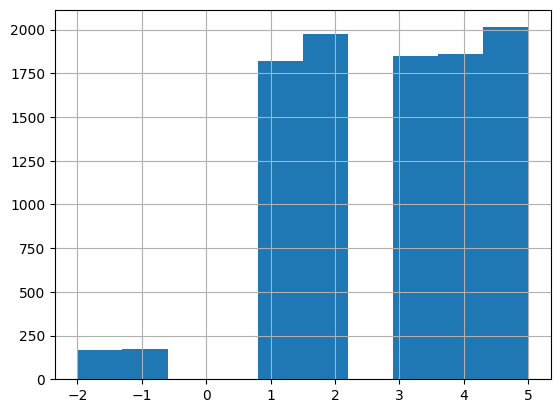

In [219]:
data[numeric_cols[0]].hist()

<Axes: >

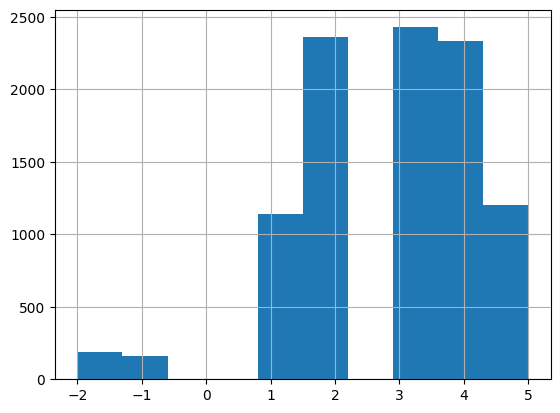

In [220]:
data[numeric_cols[1]].hist()

<Axes: >

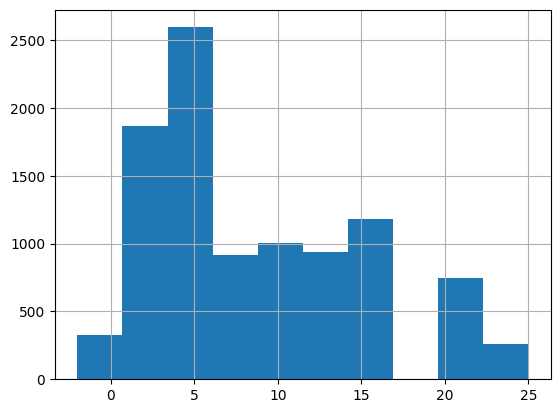

In [221]:
data[numeric_cols[2]].hist()

#### Filling missing values with skewness logic

In [222]:
data.columns

Index(['Quantity', 'Price Per Unit', 'Total Spent', 'Item_Cake', 'Item_Coffee',
       'Item_Cookie', 'Item_ERROR', 'Item_Juice', 'Item_Salad',
       'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Item_UNKNOWN',
       'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Digital Wallet', 'Payment Method_ERROR',
       'Payment Method_UNKNOWN', 'Location_ERROR', 'Location_In-store',
       'Location_Takeaway', 'Location_UNKNOWN', 'Year', 'Month', 'Day'],
      dtype='object')

In [223]:
categorical_cols = ["Payment Method", "Location", "Item"]
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent", "Year", "Month", "Day"]

encoded_cat_columns = []

for col in data.columns:
    for prefix in categorical_cols:
        if col.startswith(prefix):
            encoded_cat_columns.append(col)
            break

In [224]:
# Fill categorical variables with mode

for col in encoded_cat_columns:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)

In [225]:
# Fill missing values in numeric columns using median for skewed data and mean for symmetric data

for col in numeric_cols:
    skewness = data[col].skew()
    if abs(skewness) > 0.5:
        fill_val = data[col].median()
    else:
        fill_val = data[col].mean()

    data[col] = data[col].fillna(fill_val)

In [226]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Quantity                       10000 non-null  float64
 1   Price Per Unit                 10000 non-null  float64
 2   Total Spent                    10000 non-null  float64
 3   Item_Cake                      10000 non-null  float64
 4   Item_Coffee                    10000 non-null  float64
 5   Item_Cookie                    10000 non-null  float64
 6   Item_ERROR                     10000 non-null  float64
 7   Item_Juice                     10000 non-null  float64
 8   Item_Salad                     10000 non-null  float64
 9   Item_Sandwich                  10000 non-null  float64
 10  Item_Smoothie                  10000 non-null  float64
 11  Item_Tea                       10000 non-null  float64
 12  Item_UNKNOWN                   10000 non-null  

## Feature engineering

In [227]:
# Task: Create a flag for high-value transactions.
# If Total Spent is above 50, keep its value; if lower, set it to 0

data["HighValue"] = data["Total Spent"].where(data["Total Spent"] > 5, 0)

In [228]:
# Task: Flag items that are among the top 3 most frequently purchased

top_items = test_data["Item"].value_counts().nlargest(3).index
data["PopularItem"] = test_data["Item"].isin(top_items).astype(int)

In [229]:
# Task: Flag transactions where Total Spent < Price Per Unit * Quantity (indicates a discount)

data["Discount"] = ((data["Price Per Unit"] * data["Quantity"]) > data["Total Spent"]).astype(int)

#### Show info and correlations

In [230]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Quantity                       10000 non-null  float64
 1   Price Per Unit                 10000 non-null  float64
 2   Total Spent                    10000 non-null  float64
 3   Item_Cake                      10000 non-null  float64
 4   Item_Coffee                    10000 non-null  float64
 5   Item_Cookie                    10000 non-null  float64
 6   Item_ERROR                     10000 non-null  float64
 7   Item_Juice                     10000 non-null  float64
 8   Item_Salad                     10000 non-null  float64
 9   Item_Sandwich                  10000 non-null  float64
 10  Item_Smoothie                  10000 non-null  float64
 11  Item_Tea                       10000 non-null  float64
 12  Item_UNKNOWN                   10000 non-null  

## Visualize correlation table

In [231]:
data.corr()

,Quantity,Price Per Unit,Total Spent,Item_Cake,Item_Coffee,Item_Cookie,Item_ERROR,Item_Juice,Item_Salad,Item_Sandwich,...,Location_ERROR,Location_In-store,Location_Takeaway,Location_UNKNOWN,Year,Month,Day,HighValue,PopularItem,Discount
Quantity,1.000000,-0.001553,0.543586,0.012213,0.002661,-0.010206,-0.000090,-0.000520,-0.002265,-0.002440,...,0.008662,0.005117,0.000322,-0.020967,-0.001511,0.002461,0.002110,0.552590,-0.000075,0.041320
Price Per Unit,-0.001553,1.000000,0.483065,0.018042,-0.215528,-0.431082,0.007225,0.008619,0.454185,0.247930,...,0.010940,0.013801,-0.019274,-0.013193,-0.006288,-0.014195,-0.000847,0.475371,0.164567,0.044325
Total Spent,0.543586,0.483065,1.000000,0.014405,-0.157939,-0.322639,-0.000540,-0.000557,0.351019,0.175325,...,0.007851,0.011347,-0.015026,-0.020228,-0.010323,-0.008342,-0.001290,0.975737,0.128129,-0.272095
Item_Cake,0.012213,0.018042,0.014405,1.000000,-0.130191,-0.125528,-0.062179,-0.130570,-0.129113,-0.128031,...,0.017321,-0.015524,-0.000827,0.023518,-0.010532,0.000473,-0.013435,0.041242,-0.262162,-0.009790
Item_Coffee,0.002661,-0.215528,-0.157939,-0.130191,1.000000,-0.127140,-0.062978,-0.132246,-0.130771,-0.129674,...,-0.017963,-0.022736,-0.000722,0.018323,0.012890,0.015117,-0.003181,-0.135918,0.496605,0.008122
Item_Cookie,-0.010206,-0.431082,-0.322639,-0.125528,-0.127140,1.000000,-0.060722,-0.127510,-0.126087,-0.125030,...,-0.001887,0.001777,0.022341,-0.012259,-0.005873,0.007646,-0.017270,-0.360071,-0.256018,0.012371
Item_ERROR,-0.000090,0.007225,-0.000540,-0.062179,-0.062978,-0.060722,1.000000,-0.063161,-0.062456,-0.061933,...,0.001747,-0.001419,-0.001607,0.007002,0.009699,-0.014824,0.013368,-0.001626,-0.126816,0.005106
Item_Juice,-0.000520,0.008619,-0.000557,-0.130570,-0.132246,-0.127510,-0.063161,1.000000,-0.131151,-0.130052,...,-0.014935,0.005224,-0.008720,-0.009603,-0.003188,-0.007221,0.012324,0.029612,0.498051,-0.006378
Item_Salad,-0.002265,0.454185,0.351019,-0.129113,-0.130771,-0.126087,-0.062456,-0.131151,1.000000,-0.128601,...,-0.003543,0.016846,-0.002682,-0.003129,0.004692,-0.010011,0.014142,0.312011,0.492495,-0.013249
Item_Sandwich,-0.002440,0.247930,0.175325,-0.128031,-0.129674,-0.125030,-0.061933,-0.130052,-0.128601,1.000000,...,0.007665,0.019796,0.002208,-0.009134,-0.009162,-0.021646,0.010243,0.170932,-0.261121,0.006456


## Scaling

In [232]:
for col in numeric_cols + ["HighValue"]:
    min_val = data[col].min()
    max_val = data[col].max()
    data[col] = (data[col] - min_val) / (max_val - min_val)

In [233]:
data

,Quantity,Price Per Unit,Total Spent,Item_Cake,Item_Coffee,Item_Cookie,Item_ERROR,Item_Juice,Item_Salad,Item_Sandwich,...,Location_ERROR,Location_In-store,Location_Takeaway,Location_UNKNOWN,Year,Month,Day,HighValue,PopularItem,Discount
0,0.571429,0.571429,0.222222,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.785714,0.303030,0.00,1,0
1,0.857143,0.714286,0.518519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.500000,0.545455,0.48,0,0
2,0.857143,0.428571,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.642857,0.636364,0.00,0,1
3,0.571429,1.000000,0.444444,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.428571,0.878788,0.40,1,0
4,0.571429,0.571429,0.222222,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.571429,0.393939,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.571429,0.571429,0.222222,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.714286,0.969697,0.00,1,0
9996,0.714286,0.714286,0.185185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.571429,0.121212,0.00,0,1
9997,0.857143,0.571429,0.370370,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.357143,0.121212,0.32,1,0
9998,0.714286,0.714286,0.185185,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.000000,0.121212,0.00,0,1
